In [1]:
import numpy as np

path = "./datasets/TemporalDrift/tam_valid.npz"
data = np.load(path)
print(data.files)

['X', 'y']


In [2]:
# 比如查看前5条
print(data['X'][:5])
print(data['y'][:5])

[[[  1.   0.   0. ...   0.   0.  31.]
  [  1.   0.   0. ...   0.   0.  22.]]

 [[  1.   0.   0. ...   0.   0. 100.]
  [  1.   0.   0. ...   0.   0.  13.]]

 [[  1.   0.   0. ...   0.   0.  72.]
  [  1.   0.   0. ...   0.   0.  33.]]

 [[  1.   0.   0. ...   0.   0.  18.]
  [  0.   0.   0. ...   0.   0.   9.]]

 [[  1.   0.   0. ...   0.   0. 152.]
  [  0.   0.   0. ...   0.   1.  94.]]]
[36. 59. 18. 79. 85.]


In [5]:
print(np.shape(data['X']))
print(np.shape(data['y']))

(2160, 2, 1800)
(2160,)


## 动机

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. 加载所有数据：day14、day90、day270、原始训练集
# ======================
path = "./datasets/TemporalDrift/tam_train.npz"       # 原始流量
path14 = "./datasets/TemporalDrift/tam_day14.npz"     # day14
path90 = "./datasets/TemporalDrift/tam_day90.npz"     # day90
path270 = "./datasets/TemporalDrift/tam_day270.npz"   # day270

data = np.load(path)
data14 = np.load(path14)
data90 = np.load(path90)
data270 = np.load(path270)

X_s, y_s = data['X'], data['y']              # Source（原始）
X_t14, y_t14 = data14['X'], data14['y']     # day14
X_t90, y_t90 = data90['X'], data90['y']     # day90
X_t270, y_t270 = data270['X'], data270['y'] # day270

print("Source:", X_s.shape, y_s.shape)
print("Day14:", X_t14.shape, y_t14.shape)
print("Day90:", X_t90.shape, y_t90.shape)
print("Day270:", X_t270.shape, y_t270.shape)

# ======================
# 2. 只取类别 0
# ======================
cls = 0

X_s_cls = X_s[y_s == cls]
X_t14_cls = X_t14[y_t14 == cls]
X_t90_cls = X_t90[y_t90 == cls]
X_t270_cls = X_t270[y_t270 == cls]

# 统一样本数量，防止不一致
min_n = min(len(X_s_cls), len(X_t14_cls), len(X_t90_cls), len(X_t270_cls))
X_s_cls = X_s_cls[:min_n]
X_t14_cls = X_t14_cls[:min_n]
X_t90_cls = X_t90_cls[:min_n]
X_t270_cls = X_t270_cls[:min_n]

print("Class 0 samples (same length):", X_s_cls.shape, X_t14_cls.shape, X_t90_cls.shape, X_t270_cls.shape)

# ======================
# 3. FFT + log 幅度
# ======================
def get_spectrum(X):
    X_fft = np.fft.rfft(X, axis=2)
    X_mag = np.log1p(np.abs(X_fft))
    return X_mag

X_s_fft = get_spectrum(X_s_cls)
X_t14_fft = get_spectrum(X_t14_cls)
X_t90_fft = get_spectrum(X_t90_cls)
X_t270_fft = get_spectrum(X_t270_cls)

# ======================
# 4. 计算平均频谱
# ======================
mean_s = X_s_fft.mean(axis=0)
mean_t14 = X_t14_fft.mean(axis=0)
mean_t90 = X_t90_fft.mean(axis=0)
mean_t270 = X_t270_fft.mean(axis=0)

freq = np.arange(mean_s.shape[1])

# ======================
# 5. 绘图：4条曲线对比
# ======================
plt.figure(figsize=(10, 6))

# 绘制四条线
plt.plot(freq, mean_s[0], label='Source (Original)', linewidth=2.5)
plt.plot(freq, mean_t14[0], label='Day14', linewidth=2.5)
plt.plot(freq, mean_t90[0], label='Day90', linewidth=2.5)
plt.plot(freq, mean_t270[0], label='Day270', linewidth=2.5)

plt.xlabel("Frequency Index")
plt.ylabel("Log Magnitude")
plt.title("Class 0 Spectrum Comparison (Incoming)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Source: (19439, 10000) (19439,)
Day14: (22603, 10000) (22603,)
Day90: (28599, 10000) (28599,)
Day270: (19935, 10000) (19935,)
Class 0 samples (same length): (194, 10000) (194, 10000) (194, 10000) (194, 10000)


IndexError: tuple index out of range

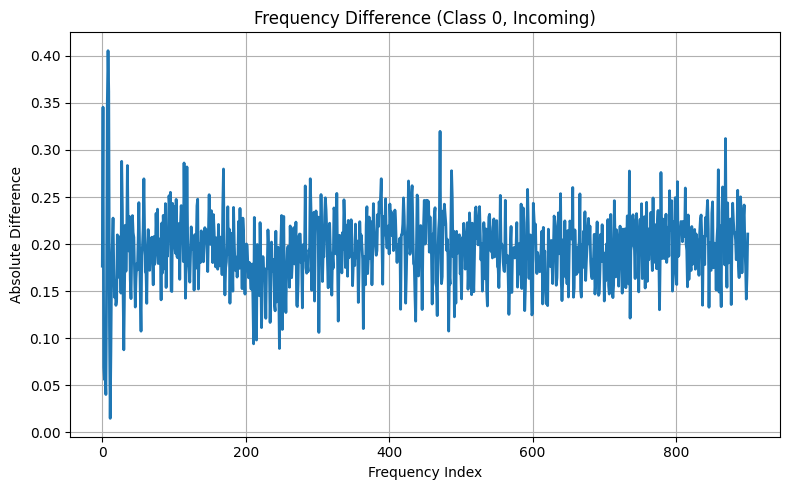

In [12]:
# ======================
# 6. 图2：频率差异（incoming）
# ======================
diff = np.abs(mean_s - mean_t)

plt.figure(figsize=(8, 5))

plt.plot(freq, diff[0], linewidth=2)

plt.xlabel("Frequency Index")
plt.ylabel("Absolute Difference")
plt.title("Frequency Difference (Class 0, Incoming)")
plt.grid()

plt.tight_layout()
plt.show()

In [13]:
# ======================
# 7. （可选）低频 vs 高频差异统计
# ======================
k = 100  # 低频范围

low_diff = diff[0][:k].mean()
high_diff = diff[0][k:].mean()

print(f"Low-frequency difference: {low_diff:.4f}")
print(f"High-frequency difference: {high_diff:.4f}")

Low-frequency difference: 0.1897
High-frequency difference: 0.1953


## 所以类别

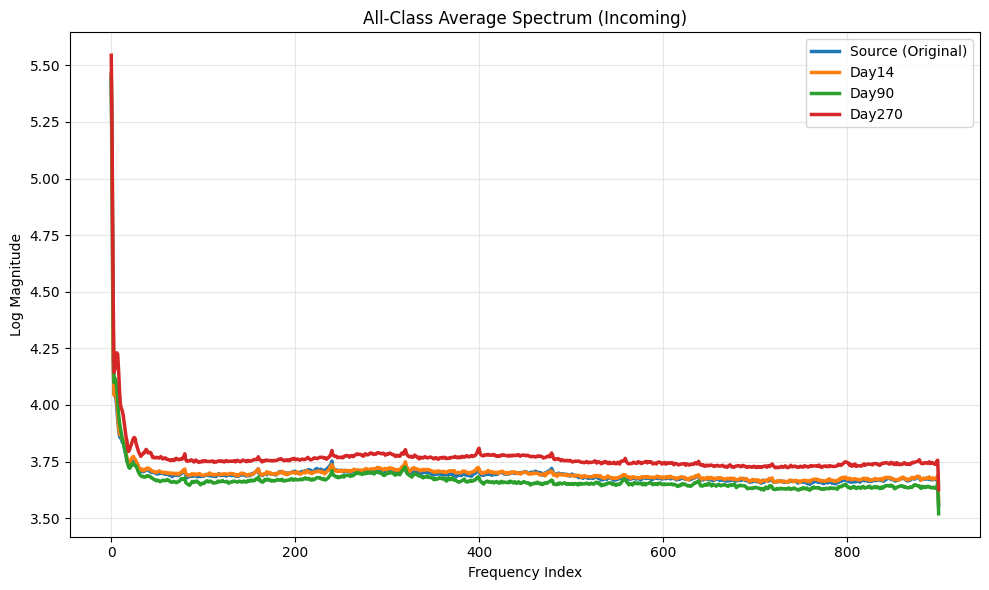

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 1. 加载所有数据
# ======================
path = "./datasets/TemporalDrift/tam_train.npz"
path14 = "./datasets/TemporalDrift/tam_day14.npz"
path90 = "./datasets/TemporalDrift/tam_day90.npz"
path270 = "./datasets/TemporalDrift/tam_day270.npz"

data = np.load(path)
data14 = np.load(path14)
data90 = np.load(path90)
data270 = np.load(path270)

X_s, y_s = data['X'], data['y']
X_t14, y_t14 = data14['X'], data14['y']
X_t90, y_t90 = data90['X'], data90['y']
X_t270, y_t270 = data270['X'], data270['y']

# ======================
# 2. FFT 函数（只定义一次）
# ======================
def get_spectrum(X):
    X_fft = np.fft.rfft(X, axis=2)
    X_mag = np.log1p(np.abs(X_fft))
    return X_mag

# ======================
# 3. 遍历所有类别，计算平均频谱
# ======================
classes = np.unique(y_s)

all_mean_s = []
all_mean_t14 = []
all_mean_t90 = []
all_mean_t270 = []

for cls in classes:
    # 取出当前类别的样本
    X_s_cls = X_s[y_s == cls]
    X_t14_cls = X_t14[y_t14 == cls]
    X_t90_cls = X_t90[y_t90 == cls]
    X_t270_cls = X_t270[y_t270 == cls]

    # 统一最小样本数
    min_n = min(len(X_s_cls), len(X_t14_cls), len(X_t90_cls), len(X_t270_cls))
    X_s_cls = X_s_cls[:min_n]
    X_t14_cls = X_t14_cls[:min_n]
    X_t90_cls = X_t90_cls[:min_n]
    X_t270_cls = X_t270_cls[:min_n]

    # 计算频谱均值,同类所有曲线平均成一条代表曲线
    mean_s_cls = get_spectrum(X_s_cls).mean(axis=0)
    mean_t14_cls = get_spectrum(X_t14_cls).mean(axis=0)
    mean_t90_cls = get_spectrum(X_t90_cls).mean(axis=0)
    mean_t270_cls = get_spectrum(X_t270_cls).mean(axis=0)

    all_mean_s.append(mean_s_cls)
    all_mean_t14.append(mean_t14_cls)
    all_mean_t90.append(mean_t90_cls)
    all_mean_t270.append(mean_t270_cls)

# ======================
# 4. 所有类别整体平均
# ======================
mean_s_all = np.mean(all_mean_s, axis=0)
mean_t14_all = np.mean(all_mean_t14, axis=0)
mean_t90_all = np.mean(all_mean_t90, axis=0)
mean_t270_all = np.mean(all_mean_t270, axis=0)

freq = np.arange(mean_s_all.shape[1])

# ======================
# 5. 绘图：4条线对比
# ======================
plt.figure(figsize=(10, 6))

plt.plot(freq, mean_s_all[0], label='Source (Original)', linewidth=2.5)
plt.plot(freq, mean_t14_all[0], label='Day14', linewidth=2.5)
plt.plot(freq, mean_t90_all[0], label='Day90', linewidth=2.5)
plt.plot(freq, mean_t270_all[0], label='Day270', linewidth=2.5)

plt.xlabel("Frequency Index")
plt.ylabel("Log Magnitude")
plt.title("All-Class Average Spectrum (Incoming)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

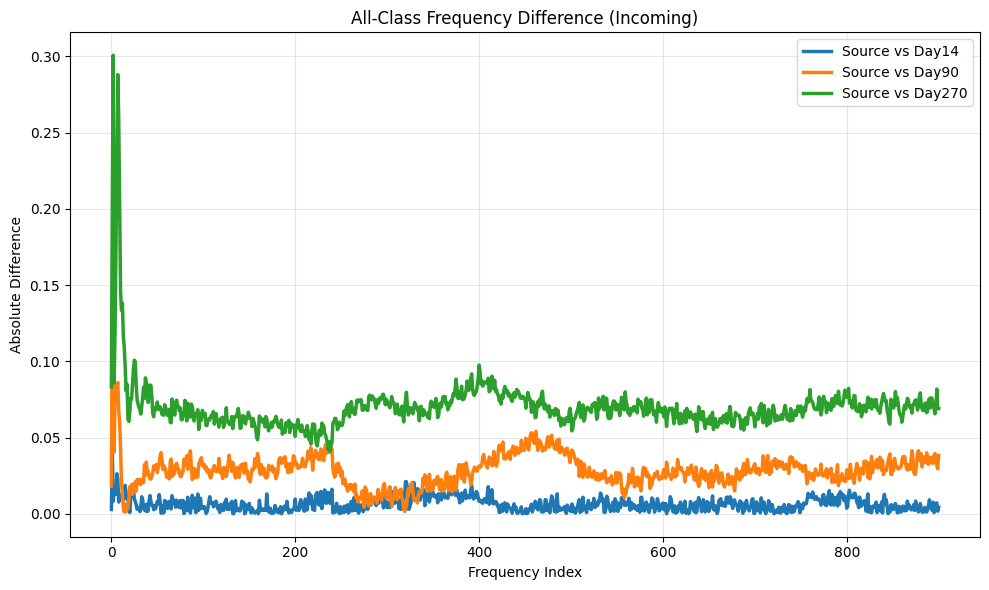

In [4]:
# ======================
# 5. 计算三条差值曲线（你要改的部分）
# ======================
diff_day14 = np.abs(mean_s_all - mean_t14_all)
diff_day90 = np.abs(mean_s_all - mean_t90_all)
diff_day270 = np.abs(mean_s_all - mean_t270_all)

# ======================
# 6. 绘制三条差值对比图
# ======================
plt.figure(figsize=(10, 6))
plt.plot(freq, diff_day14[0], label='Source vs Day14', linewidth=2.5)
plt.plot(freq, diff_day90[0], label='Source vs Day90', linewidth=2.5)
plt.plot(freq, diff_day270[0], label='Source vs Day270', linewidth=2.5)

plt.xlabel("Frequency Index")
plt.ylabel("Absolute Difference")
plt.title("All-Class Frequency Difference (Incoming)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
k = 100  # 低频范围
low_diff = diff_all[0][:k].mean()
high_diff = diff_all[0][k:].mean()
print(f"Low-frequency difference: {low_diff:.4f}")
print(f"High-frequency difference: {high_diff:.4f}")

Low-frequency difference: 0.0865
High-frequency difference: 0.0678


# 新的频域转化

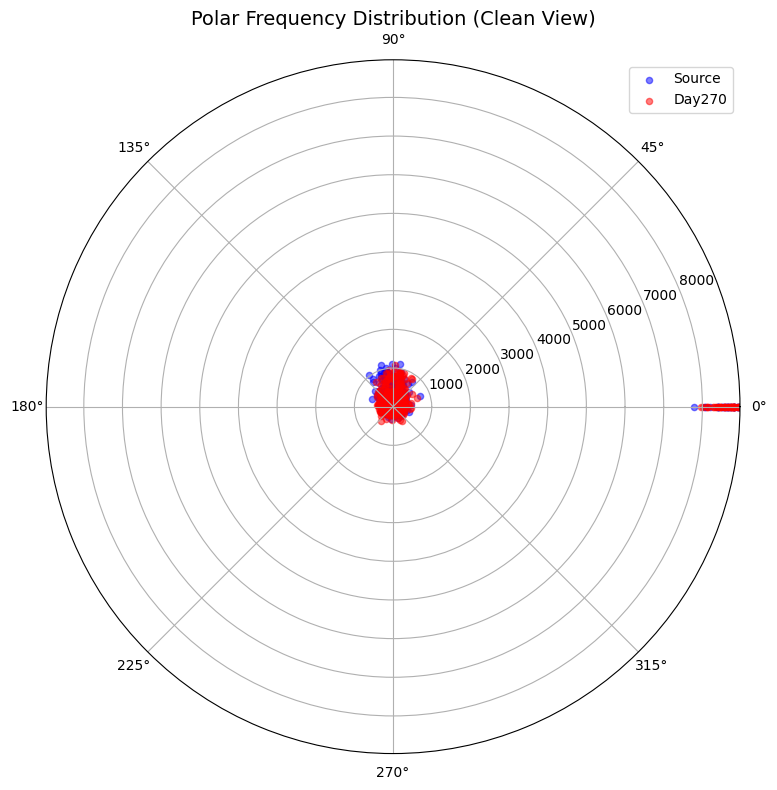

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# 频域提取
# ======================
def get_spectrum(X, modes=64):   # 👉 降低频率维度
    if X.ndim == 2:
        X = X[:, np.newaxis, :]

    X = np.cos(X)
    X_fft = np.fft.rfft(X, axis=-1)[:, :, :modes]

    amp = np.abs(X_fft)
    phase = np.angle(X_fft)

    return amp, phase

# ======================
# 极坐标采样（重点优化）
# ======================
def sample_polar(amp, phase, sample_n=50):  # 👉 大幅减少样本
    B = amp.shape[0]
    idx = np.random.choice(B, min(sample_n, B), replace=False)

    amp = amp[idx, 0, :].flatten()
    phase = phase[idx, 0, :].flatten()

    # 再次降采样频率点
    step = 4  # 👉 每4个频率取1个
    amp = amp[::step]
    phase = phase[::step]

    return phase, amp

# ======================
# 参数
# ======================
modes = 64   # 👉 从256降到64（关键）

amp_s, phase_s = get_spectrum(X_s_cls, modes)
amp_t14, phase_t14 = get_spectrum(X_t14_cls, modes)
amp_t90, phase_t90 = get_spectrum(X_t90_cls, modes)
amp_t270, phase_t270 = get_spectrum(X_t270_cls, modes)

ps, as_ = sample_polar(amp_s, phase_s)
p14, a14 = sample_polar(amp_t14, phase_t14)
p90, a90 = sample_polar(amp_t90, phase_t90)
p270, a270 = sample_polar(amp_t270, phase_t270)

# ======================
# 极坐标图（清爽版）
# ======================
plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')

ax.scatter(ps, as_, s=20, alpha=0.5, c='blue', label='Source')
# ax.scatter(p14, a14, s=20, alpha=0.5, c='orange', label='Day14')
# ax.scatter(p90, a90, s=20, alpha=0.5, c='green', label='Day90')
ax.scatter(p270, a270, s=20, alpha=0.5, c='red', label='Day270')

# 👉 自动缩放（去极端值）
all_amp = np.concatenate([as_, a14, a90, a270])
ax.set_rlim(0, np.percentile(all_amp, 98))

ax.set_title("Polar Frequency Distribution (Clean View)", fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()